=== Summary ===
Image ID: ISIC_0024402
Location: back
Color Descriptor: reddish | hex=#C747A8 | share=60.6%
Surface Roughness: rough | SRI=2.144
Border Regularity: regular | BII=0.068
Size Category: small (area ratio 3.3%) [relative]
Redness Level: severe (29.3%)
Synthetic Symptom Note:
A rough, reddish lesion on the back with regular borders, small in size and showing severe redness.


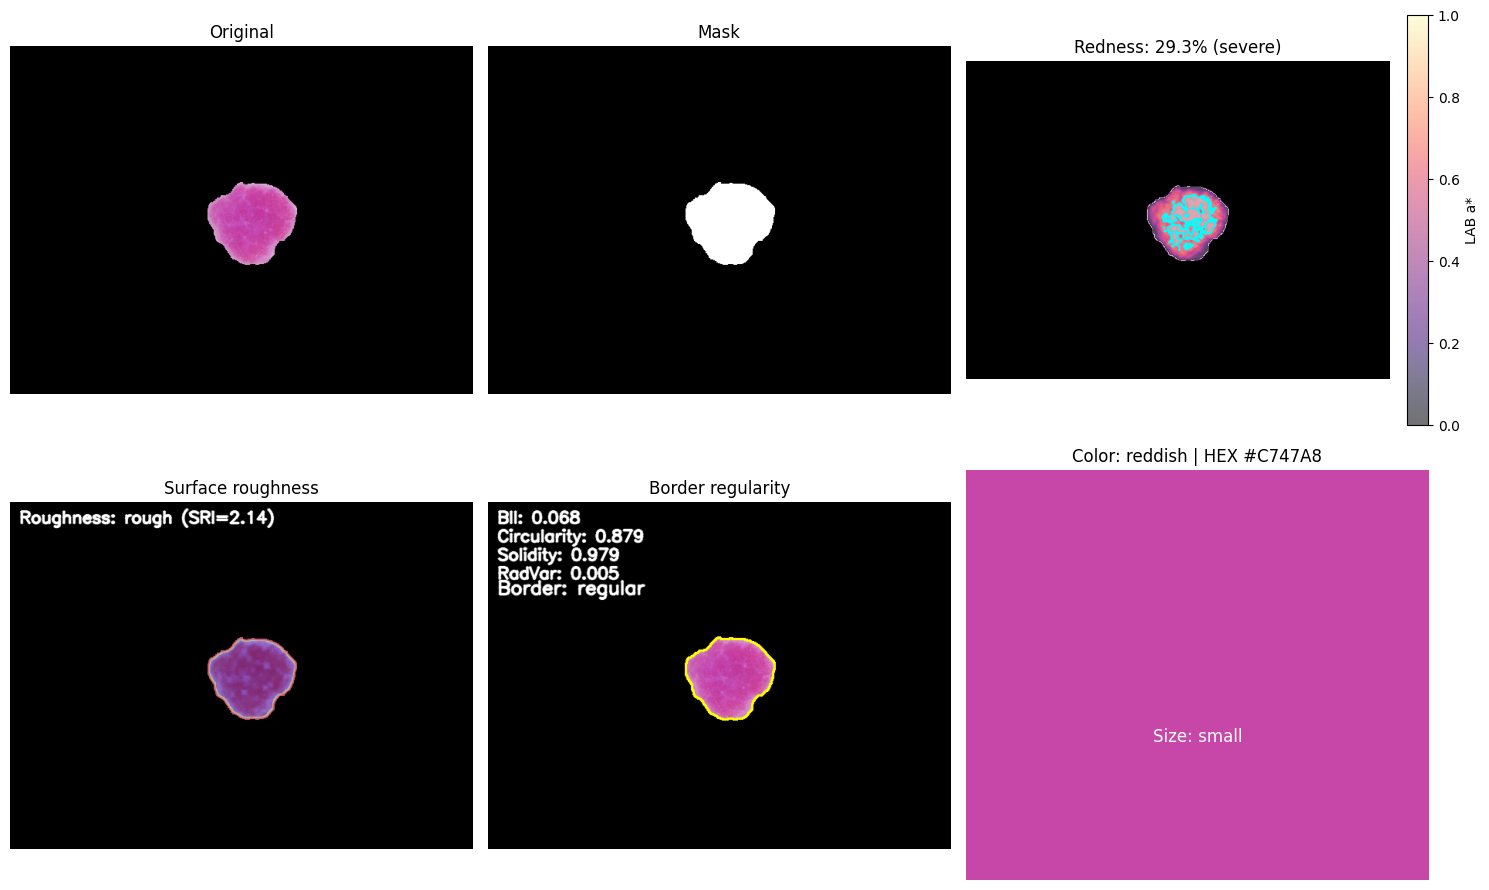

Saved panel to: outputs_all\ISIC_0024402_panel.png


In [1]:
# ==========================================
# Unified Symptom Extraction Pipeline
# ==========================================
# Fields covered here:
#   - Color Descriptor
#   - Surface Roughness
#   - Border Regularity
#   - Size Category
#   - Redness Level
#   - Synthetic Symptom Note (composed)
#
# Location is read from metadata.csv (column: localization) by matching image_id,
# then passed to compose_note().
# ==========================================

import os, csv
import cv2, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from math import pi
from skimage import measure
from skimage.feature import local_binary_pattern
from scipy.signal import savgol_filter

# ----------------------------
# Common helpers
# ----------------------------
def bgr2rgb(x): return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

def make_mask_from_black(img_bgr, thr=8):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > thr).astype(np.uint8)
    n, lab = cv2.connectedComponents(mask)
    if n > 1:
        cnts = np.bincount(lab.ravel()); cnts[0] = 0
        mask = (lab == np.argmax(cnts)).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8), 1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3,3), np.uint8), 1)
    return mask

def gray_world_white_balance(bgr):
    bgr = bgr.astype(np.float32)
    mean_bgr = bgr.reshape(-1,3).mean(axis=0) + 1e-6
    gray = mean_bgr.mean()
    scale = gray / mean_bgr
    wb = np.clip(bgr * scale, 0, 255).astype(np.uint8)
    return wb

def shades_of_gray_wb(bgr, p=6):
    img = bgr.astype(np.float32) + 1e-6
    B, G, R = cv2.split(img)
    rb = np.mean(R**p)**(1.0/p)
    gb = np.mean(G**p)**(1.0/p)
    bb = np.mean(B**p)**(1.0/p)
    meanI = (rb + gb + bb)/3.0
    scale = (meanI/bb, meanI/gb, meanI/rb)
    out = cv2.merge([B*scale[0], G*scale[1], R*scale[2]])
    return np.clip(out, 0, 255).astype(np.uint8)

def specular_mask(bgr, v_thr=240, s_thr=25):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    V, S = hsv[...,2], hsv[...,1]
    return ((V >= v_thr) & (S <= s_thr)).astype(np.uint8)

def to_hex(rgb):
    return "#{:02X}{:02X}{:02X}".format(*np.clip(np.round(rgb),0,255).astype(int))

# ----------------------------
# Metadata helpers
# ----------------------------
def get_location_and_meta_for_image(meta_csv_path, image_path):
    """
    Returns (meta_row, location).
    - meta_row: dict with keys compatible with compute_size_category helpers
    - location: from 'localization' column (case-insensitive), with fallbacks
    """
    image_id = os.path.splitext(os.path.basename(image_path))[0]

    if not (meta_csv_path and os.path.exists(meta_csv_path)):
        return None, None

    def norm_val(x):
        if x is None:
            return None
        s = str(x).strip()
        return None if s == "" or s.lower() == "nan" else s

    # Fallback column names for location if 'localization' is missing
    location_keys = ["localization", "anatom_site_general", "anatom_site_general_challenge", "anatom_site"]

    with open(meta_csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            # Normalize keys to lowercase for robust matching
            row_lc = {(k or "").strip().lower(): norm_val(v) for k, v in row.items()}

            # Resolve the image id field
            rid = row_lc.get("image_id") or row_lc.get("filename") or row_lc.get("image") or row_lc.get("name")
            if rid:
                rid = os.path.splitext(os.path.basename(rid))[0]

            if rid == image_id:
                # Pull location (prefer 'localization')
                location = None
                for lk in location_keys:
                    if row_lc.get(lk) is not None:
                        location = row_lc[lk]
                        break

                # Build a meta_row dict compatible with size extraction functions
                meta_row = {}
                # Canonical numeric keys expected by try_extract_* helpers:
                canonical_keys = [
                    "mm_per_pixel", "pixel_spacing_mm", "physical_pixel_spacing_mm",
                    "x_mm_per_px", "y_mm_per_px",
                    "clin_size_long_diameter_mm", "lesion_diameter_mm",
                    "lesion_size_long_diameter_mm", "diameter_mm", "size_mm",
                ]
                for k in canonical_keys:
                    if row_lc.get(k) is not None:
                        meta_row[k] = row_lc[k]
                return (meta_row if meta_row else None), location

    return None, None

# ----------------------------
# Redness Level
# ----------------------------
def redness_metrics(orig_bgr, lesion_mask, a_abs_thr=15, rel_pct=70):
    wb = gray_world_white_balance(orig_bgr)
    spec = specular_mask(wb)
    lesion_core = (lesion_mask.astype(bool) & (~spec.astype(bool)))

    lab = cv2.cvtColor(wb, cv2.COLOR_BGR2LAB)
    A = lab[...,1].astype(np.int16)  # 0..255 with 128 as zero
    a_star = A - 128

    vals = a_star[lesion_core]
    if vals.size == 0:
        return dict(ratio=0.0, level="none", mean_hex="#000000",
                    red_mask=np.zeros_like(lesion_mask, np.uint8))

    thr_rel = np.percentile(vals, rel_pct)
    thr = max(a_abs_thr, thr_rel)
    red_mask = (a_star > thr) & lesion_core
    ratio = float(red_mask.sum()) / float(lesion_core.sum())

    ys, xs = np.where(red_mask)
    mean_bgr = orig_bgr[ys, xs].mean(axis=0) if len(ys) else np.array([0,0,0], float)
    mean_rgb = mean_bgr[::-1]
    mean_hex = "#{:02X}{:02X}{:02X}".format(*np.clip(np.round(mean_rgb),0,255).astype(int))

    pct = ratio*100
    if pct < 3: level = "none"
    elif pct < 8: level = "mild"
    elif pct < 20: level = "moderate"
    else: level = "severe"

    return dict(ratio=ratio, level=level, mean_hex=mean_hex, red_mask=red_mask.astype(np.uint8))

def build_redness_heat(orig_bgr, lesion_mask):
    orig_rgb = bgr2rgb(orig_bgr)
    wb = gray_world_white_balance(orig_bgr)
    lab = cv2.cvtColor(wb, cv2.COLOR_BGR2LAB)
    a_star = lab[...,1].astype(np.int16) - 128
    spec = specular_mask(wb)
    lesion_core = lesion_mask.astype(bool) & (~spec.astype(bool))

    heat = np.zeros_like(a_star, dtype=np.float32)
    if lesion_core.any():
        vals = a_star[lesion_core]
        vmin, vmax = np.percentile(vals, [5, 95])
        if vmin == vmax:
            vmin -= 1; vmax += 1
        heat = np.clip((a_star - vmin) / (vmax - vmin), 0, 1)
        heat[~lesion_core] = np.nan
    return orig_rgb, heat

# ----------------------------
# Surface Roughness + Border Regularity
# ----------------------------
def ensure_odd(n):
    n = int(n); return n if n % 2 == 1 else n + 1

def lesion_window_size(mask, frac=0.05, mi=7, ma=41):
    ys, xs = np.where(mask > 0)
    if ys.size == 0: return mi
    d = max(ys.max()-ys.min()+1, xs.max()-xs.min()+1)
    return ensure_odd(int(np.clip(d * frac, mi, ma)))

def crofton_perimeter(mask_bool):
    return float(measure.perimeter_crofton(mask_bool.astype(bool), directions=4))

def resample_contour_uniform(contour, n=512, smooth_win=21, poly=3):
    pts = contour.squeeze().astype(np.float64)
    if pts.ndim != 2 or pts.shape[0] < 5: return pts
    if np.all(pts[0] == pts[-1]): pts = pts[:-1]
    d = np.sqrt(np.sum(np.diff(pts, axis=0)**2, axis=1))
    s = np.hstack(([0.0], np.cumsum(d)))
    if s[-1] == 0: return pts
    t = np.linspace(0, s[-1], n)
    x = np.interp(t, s, pts[:,0]); y = np.interp(t, s, pts[:,1])
    win = min(smooth_win, n - (1 - n % 2)); win = max(win, 5)
    if win % 2 == 0: win += 1
    x = savgol_filter(x, win, poly, mode='interp')
    y = savgol_filter(y, win, poly, mode='interp')
    return np.column_stack([x, y])

def curvature_from_polyline(pts):
    dx = np.gradient(pts[:,0]); dy = np.gradient(pts[:,1])
    ddx = np.gradient(dx);       ddy = np.gradient(dy)
    denom = (dx*dx + dy*dy)**1.5 + 1e-9
    return np.abs(dx*ddy - dy*ddx) / denom

def remove_specular(img_bgr, mask, v_thr=0.97, s_thr=0.10):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    S = hsv[:,:,1]/255.0; V = hsv[:,:,2]/255.0
    spec = (V > v_thr) & (S < s_thr)
    valid = (mask > 0) & (~spec)
    return valid.astype(np.uint8), spec.astype(np.uint8)

def local_std_map(gray, ksize):
    g = gray.astype(np.float32)
    m1 = cv2.blur(g, (ksize, ksize))
    m2 = cv2.blur(g*g, (ksize, ksize))
    return np.sqrt(np.clip(m2 - m1*m1, 0, None))

def overlay_heatmap(img_bgr, value, mask, cmap=cv2.COLORMAP_TURBO, alpha=0.45, clip=(1,99)):
    m = mask.astype(bool)
    v = value.copy().astype(np.float32)
    if np.any(m):
        lo, hi = np.percentile(v[m], clip)
        v = (v - lo) / (hi - lo + 1e-6)
    v = np.clip(v, 0, 1)
    disp = (v*255).astype(np.uint8); disp[~m] = 0
    heat = cv2.applyColorMap(disp, cmap)
    out = (alpha*heat + (1-alpha)*img_bgr).astype(np.uint8)
    out[~m] = img_bgr[~m]
    return out

def compute_border_metrics(mask):
    A = float(mask.sum())
    P = crofton_perimeter(mask)
    circularity = (4*pi*A)/(P**2 + 1e-9) if P>0 else 0.0

    cnts, _ = cv2.findContours((mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(cnts, key=cv2.contourArea) if cnts else None
    if c is None: return None

    hull = cv2.convexHull(c)
    A_convex = float(cv2.contourArea(hull)) + 1e-9
    solidity = float(A / A_convex)

    M = cv2.moments(c); cx, cy = M['m10']/M['m00'], M['m01']/M['m00']
    pts = c[:,0,:]
    r = np.sqrt((pts[:,0]-cx)**2 + (pts[:,1]-cy)**2)
    radial_var = float(np.var(r)/(np.mean(r)**2 + 1e-9))

    cs = resample_contour_uniform(c, n=512, smooth_win=21, poly=3)
    kappa = curvature_from_polyline(cs)
    curv_mean, curv_std = float(np.mean(kappa)), float(np.std(kappa))

    z = cs[:,0] + 1j*cs[:,1]; z -= z.mean()
    F = np.fft.fft(z); mag = np.abs(F); mag = mag/(mag[1] + 1e-9)
    hf_ratio = float(np.sum(mag[8:]**2) / (np.sum(mag**2) + 1e-9))

    BII = 0.5*(1 - circularity) + 0.3*(1 - solidity) + 0.2*np.clip(radial_var, 0, 1)

    return {"area_px":A, "perimeter_crofton":P, "circularity":circularity,
            "solidity":solidity, "radial_variance":radial_var,
            "curvature_mean":curv_mean, "curvature_std":curv_std,
            "fourier_hf_ratio":hf_ratio, "BII":float(BII),
            "contour":c, "contour_smooth":cs}

def compute_surface_metrics(img_bgr, mask):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:,:,0]

    k = lesion_window_size(mask, frac=0.05, mi=7, ma=41)
    std_map = local_std_map(L, k)

    gx = cv2.Sobel(L, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(L, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(gx**2 + gy**2)

    valid_mask, spec_mask = remove_specular(img_bgr, mask)
    m = valid_mask.astype(bool)
    std_vals, grad_vals = std_map[m], grad_mag[m]

    std_p90  = float(np.percentile(std_vals, 90)) if std_vals.size else 0.0
    grad_p90 = float(np.percentile(grad_vals, 90)) if grad_vals.size else 0.0

    def lbp_entropy(gray, mask, P, R):
        lbp = local_binary_pattern(gray, P, R, method='uniform')
        vals = lbp[mask.astype(bool)]
        n_bins = P + 2
        hist, _ = np.histogram(vals, bins=np.arange(n_bins+1), density=True)
        hist = hist + 1e-12
        return float(-np.sum(hist*np.log2(hist)))

    lbp_ent = float((lbp_entropy(L, valid_mask, 8, 1) + lbp_entropy(L, valid_mask, 16, 2))/2.0)

    SRI = 0.5*(std_p90/20.0) + 0.3*(grad_p90/40.0) + 0.2*((lbp_ent-1.5)/1.5)

    mu, sigma = (np.mean(std_vals), np.std(std_vals) + 1e-6) if std_vals.size else (0.0, 1.0)
    rough_z = np.zeros_like(std_map, dtype=np.float32); rough_z[mask>0] = (std_map[mask>0] - mu) / sigma

    return {"std_p90":std_p90, "grad_p90":grad_p90, "lbp_entropy_ms":lbp_ent,
            "SRI":float(SRI), "rough_z":rough_z,
            "specular_fraction":float(np.mean(spec_mask[mask>0])), "ksize":int(k)}

def draw_border_overlay(img_bgr, mask, border_metrics):
    vis = img_bgr.copy()
    cv2.drawContours(vis, [border_metrics["contour"]], -1, (0,255,255), 2)
    y = 28
    for t in [f'BII: {border_metrics["BII"]:.3f}',
              f'Circularity: {border_metrics["circularity"]:.3f}',
              f'Solidity: {border_metrics["solidity"]:.3f}',
              f'RadVar: {border_metrics["radial_variance"]:.3f}']:
        cv2.putText(vis, t, (12, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
        y += 24
    return vis

def classify_border(border):
    bii = border["BII"]; circ = border["circularity"]; sol = border["solidity"]; rvar = border["radial_variance"]
    if (bii < 0.10) and (circ >= 0.85) and (rvar <= 0.015) and (sol >= 0.93):
        label = "regular"
    elif (bii >= 0.22) or (circ < 0.80) or (rvar > 0.03) or (sol < 0.90):
        label = "irregular"
    else:
        label = "mildly_irregular"
    conf = float(np.clip(1.0 - bii/0.35, 0, 1))
    return label, conf

def classify_surface(surface):
    SRI  = surface["SRI"]; lbp = surface["lbp_entropy_ms"]; grad = surface["grad_p90"]; spec = surface["specular_fraction"]
    if (SRI >= 3.5) or (spec >= 0.005):
        label = "keratotic"
    elif (SRI >= 2.0) or (lbp >= 3.2):
        label = "rough"
    elif (SRI >= 1.0):
        label = "mildly_rough"
    else:
        label = "smooth" if (grad < 60 and lbp < 2.6) else "mildly_rough"
    edges = np.array([0.0, 1.0, 2.0, 3.5], dtype=float)
    dmin = float(np.min(np.abs(SRI - edges)))
    conf = float(np.clip(dmin/1.5, 0, 1))
    return label, conf

# ----------------------------
# Color Descriptor (robust vote)
# ----------------------------
def compute_color_descriptor_robust(orig_bgr, mask,
                                    gray_C_thr=9.0, gray_ab_thr=8.0,
                                    pink_a_thr=16.0, pink_L_thr=68.0,
                                    red_a_thr=22.0,
                                    brown_a_thr=6.0, brown_b_thr=12.0,
                                    light_dark_L_cut=55.0,
                                    min_share=0.35, min_gap=0.07):
    wb = shades_of_gray_wb(orig_bgr, p=6)
    hsv = cv2.cvtColor(wb, cv2.COLOR_BGR2HSV)
    spec = ((hsv[...,2] > 240) & (hsv[...,1] < 25))
    lesion_core = (mask.astype(bool) & (~spec))

    if not np.any(lesion_core):
        return dict(label="unknown", dominant_hex="#000000", dominant_share=0.0,
                    shares_by_class={}, used_pixels=0)

    lab = cv2.cvtColor(wb, cv2.COLOR_BGR2LAB)
    Lcv, Acv, Bcv = lab[...,0], lab[...,1], lab[...,2]

    ys, xs = np.where(lesion_core)
    Ls  = Lcv[ys, xs].astype(np.float32) * (100.0/255.0)
    a_s = Acv[ys, xs].astype(np.float32) - 128.0
    b_s = Bcv[ys, xs].astype(np.float32) - 128.0
    C   = np.hypot(a_s, b_s)
    total = float(Ls.size)

    black  = (Ls < 22)
    gray   = (~black) & (C < gray_C_thr) & (np.abs(a_s) < gray_ab_thr) & (np.abs(b_s) < gray_ab_thr) & (35 <= Ls) & (Ls <= 85)
    pink   = (~black) & (~gray) & (Ls >= pink_L_thr) & (a_s >= pink_a_thr)
    reddish= (~black) & (~gray) & (~pink) & (a_s >= red_a_thr)
    brownish = (~black) & (~gray) & (~pink) & (~reddish) & (a_s >= brown_a_thr) & (b_s >= brown_b_thr)
    light_brown = brownish & (Ls >= light_dark_L_cut)
    dark_brown  = brownish & (Ls <  light_dark_L_cut)

    assigned = black | gray | pink | reddish | light_brown | dark_brown
    rest = ~assigned
    light_brown |= (rest & (Ls >= light_dark_L_cut))
    dark_brown  |= (rest & (Ls <  light_dark_L_cut))

    shares = {
        "light_brown":  float(np.count_nonzero(light_brown))/total,
        "dark_brown":   float(np.count_nonzero(dark_brown))/total,
        "reddish":      float(np.count_nonzero(reddish))/total,
        "pink":         float(np.count_nonzero(pink))/total,
        "gray":         float(np.count_nonzero(gray))/total,
        "black":        float(np.count_nonzero(black))/total,
    }
    ordered = sorted(shares.items(), key=lambda kv: kv[1], reverse=True)
    label, s1 = ordered[0]
    s2 = ordered[1][1] if len(ordered) > 1 else 0.0
    if (s1 < min_share) or ((s1 - s2) < min_gap):
        label = "mixed"

    lesion_rgb = orig_bgr[..., ::-1]
    if label == "mixed":
        full_sel = mask.astype(bool)
    else:
        sel = {
            "light_brown": light_brown, "dark_brown": dark_brown,
            "reddish": reddish, "pink": pink, "gray": gray, "black": black
        }[label]
        # Map 1D selection back to full image indices
        full_sel = np.zeros(mask.shape, dtype=bool)
        full_sel[ys, xs] = sel

    if not np.any(full_sel):
        full_sel = mask.astype(bool)

    mean_rgb = lesion_rgb[full_sel].mean(axis=0)
    hex_color = to_hex(mean_rgb)

    return dict(label=label, dominant_hex=hex_color, dominant_share=float(s1),
                shares_by_class=shares, used_pixels=int(total))

def show_color_descriptor(orig_bgr, mask, desc):
    orig_rgb = bgr2rgb(orig_bgr)
    fig = plt.figure(figsize=(12,4))
    gs = fig.add_gridspec(1,3, width_ratios=[1,1,0.9])
    ax0 = fig.add_subplot(gs[0,0]); ax0.imshow(orig_rgb); ax0.set_title("Original"); ax0.axis("off")
    ax1 = fig.add_subplot(gs[0,1]); ax1.imshow(mask, cmap="gray"); ax1.set_title("Mask"); ax1.axis("off")
    ax2 = fig.add_subplot(gs[0,2])
    ax2.add_patch(Rectangle((0,0), 1, 1, color=desc["dominant_hex"]))
    ax2.set_xlim(0,1); ax2.set_ylim(0,1); ax2.axis("off")
    r = int(desc["dominant_hex"][1:3],16); g = int(desc["dominant_hex"][3:5],16); b = int(desc["dominant_hex"][5:7],16)
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    txt_color = "black" if lum > 140 else "white"
    ax2.text(0.5, 0.68, f"Color: {desc['label']}", ha="center", va="center", color=txt_color, fontsize=15)
    ax2.text(0.5, 0.48, f"HEX: {desc['dominant_hex']}", ha="center", va="center", color=txt_color, fontsize=12)
    ax2.text(0.5, 0.30, f"share={desc['dominant_share']*100:.1f}%", ha="center", va="center", color=txt_color, fontsize=10)
    plt.tight_layout(); plt.show()

# ----------------------------
# Size Category
# ----------------------------
def get_region_axes_px(mask):
    lab = measure.label(mask.astype(bool))
    props = measure.regionprops(lab)
    if not props:
        return 0.0, 0.0
    r = max(props, key=lambda p: p.area)
    return float(r.major_axis_length), float(r.minor_axis_length)

def effective_diameter_px(area_px):
    return 2.0 * np.sqrt(float(area_px) / pi)

def try_extract_mm_per_pixel_from_meta(meta_row):
    if meta_row is None:
        return None, "none"
    for k in ["mm_per_pixel", "pixel_spacing_mm", "physical_pixel_spacing_mm",
              "x_mm_per_px", "y_mm_per_px"]:
        if k in meta_row and meta_row[k] not in (None, "", "nan"):
            val = meta_row[k]
            try:
                if isinstance(val, str) and ";" in val:
                    xs, ys = val.split(";")
                    xs, ys = float(xs), float(ys)
                    return float((xs + ys)/2.0), f"meta:{k}"
                return float(val), f"meta:{k}"
            except Exception:
                pass
    return None, "none"

def try_extract_long_diameter_mm(meta_row):
    if meta_row is None:
        return None, "none"
    for k in ["clin_size_long_diameter_mm", "lesion_diameter_mm",
              "lesion_size_long_diameter_mm", "diameter_mm", "size_mm"]:
        if k in meta_row and meta_row[k] not in (None, "", "nan"):
            try:
                return float(meta_row[k]), k
            except Exception:
                pass
    return None, "none"

def size_category_from_mm(d_mm):
    if d_mm is None: return None
    if d_mm < 5.0: return "small"
    if d_mm <= 10.0: return "medium"
    return "large"

def size_category_from_relative(area_ratio, d_eff_px):
    if area_ratio < 0.04: return "small"
    if area_ratio <= 0.12: return "medium"
    return "large"

def compute_size_category(img_bgr, mask, meta_row=None):
    H, W = mask.shape
    area_px = int(mask.sum())
    if area_px == 0:
        return dict(method="none", area_px=0, area_ratio=0.0, eff_diam_px=0.0,
                    major_axis_px=0.0, minor_axis_px=0.0,
                    mm_per_px=None, diameter_mm=None, category=None)

    eff_px = effective_diameter_px(area_px)
    major_px, minor_px = get_region_axes_px(mask)
    area_ratio = area_px / float(H*W)

    mm_per_px, mpp_src = try_extract_mm_per_pixel_from_meta(meta_row)
    diam_mm_meta, diam_key = try_extract_long_diameter_mm(meta_row)
    infer_used = False
    if mm_per_px is None and diam_mm_meta is not None and major_px > 0:
        mm_per_px = diam_mm_meta / major_px
        infer_used = True

    d_mm = None
    method = "relative"
    if mm_per_px is not None:
        d_mm = eff_px * mm_per_px
        method = f"metric({mpp_src})" if not infer_used else f"inferred({diam_key}/major_axis)"
        cat = size_category_from_mm(d_mm)
    else:
        cat = size_category_from_relative(area_ratio, eff_px)

    return dict(
        method=method, area_px=int(area_px), area_ratio=float(area_ratio),
        eff_diam_px=float(eff_px), major_axis_px=float(major_px), minor_axis_px=float(minor_px),
        mm_per_px=(None if mm_per_px is None else float(mm_per_px)),
        diameter_mm=(None if d_mm is None else float(d_mm)), category=cat
    )

# ----------------------------
# Synthetic Symptom Note
# ----------------------------
def compose_note(location, color_label, surface_label, border_label, size_cat, redness_level):
    loc_text = (location or "unspecified location").replace("_", " ").strip()

    # descriptors
    surface_txt = surface_label.replace("_", " ") if surface_label else None
    color_txt = color_label.replace("_", "-") if color_label else None
    desc = ", ".join([p for p in [surface_txt, color_txt] if p]) or "skin"

    # borders
    borders = (border_label or "unspecified").replace("_", " ")

    # size phrase
    size_phrase = None
    if size_cat:
        if size_cat.lower() in ("small", "medium", "large"):
            size_phrase = f"{size_cat.lower()} in size"
        else:
            size_phrase = size_cat.replace("_", " ")

    # redness phrase
    red_phrase = None
    if redness_level:
        rl = redness_level.lower()
        red_phrase = "without visible redness" if rl == "none" else f"showing {rl} redness"

    # trailing flow
    trailing = None
    if size_phrase and red_phrase:
        trailing = f"{size_phrase} and {red_phrase}"
    elif size_phrase:
        trailing = size_phrase
    elif red_phrase:
        trailing = red_phrase

    note = f"A {desc} lesion on the {loc_text} with {borders} borders"
    note += f", {trailing}." if trailing else "."
    return note

# ----------------------------
# Visualization panel
# ----------------------------
def visualize_all(orig_bgr, mask, redness_out, surface, surface_label, border, border_label, color_desc, size_info, save_path=None):
    orig_rgb, heat = build_redness_heat(orig_bgr, mask)

    rough_overlay = overlay_heatmap(orig_bgr, surface["rough_z"], mask, alpha=0.45)
    rough_overlay = rough_overlay.copy()
    cv2.putText(rough_overlay, f"Roughness: {surface_label} (SRI={surface['SRI']:.2f})", (12, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

    border_overlay = draw_border_overlay(orig_bgr, mask, border)
    border_overlay = border_overlay.copy()
    cv2.putText(border_overlay, f"Border: {border_label}", (12, 120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)

    fig = plt.figure(figsize=(15,9))
    gs = fig.add_gridspec(2,3, height_ratios=[1,1])

    ax0 = fig.add_subplot(gs[0,0]); ax0.imshow(orig_rgb); ax0.set_title("Original"); ax0.axis("off")
    ax1 = fig.add_subplot(gs[0,1]); ax1.imshow(mask, cmap="gray"); ax1.set_title("Mask"); ax1.axis("off")

    ax2 = fig.add_subplot(gs[0,2])
    ax2.imshow(orig_rgb)
    im = ax2.imshow(heat, cmap="magma", alpha=0.55)
    ax2.contour(redness_out["red_mask"], levels=[0.5], colors="cyan", linewidths=1.2)
    ax2.set_title(f"Redness: {redness_out['ratio']*100:.1f}% ({redness_out['level']})")
    ax2.axis("off")
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04); cbar.set_label("LAB a*")

    ax3 = fig.add_subplot(gs[1,0]); ax3.imshow(bgr2rgb(rough_overlay)); ax3.set_title("Surface roughness"); ax3.axis("off")
    ax4 = fig.add_subplot(gs[1,1]); ax4.imshow(bgr2rgb(border_overlay)); ax4.set_title("Border regularity"); ax4.axis("off")

    ax5 = fig.add_subplot(gs[1,2])
    ax5.add_patch(Rectangle((0,0), 1, 1, color=color_desc["dominant_hex"]))
    ax5.set_xlim(0,1); ax5.set_ylim(0,1); ax5.axis("off")
    r = int(color_desc["dominant_hex"][1:3],16); g = int(color_desc["dominant_hex"][3:5],16); b = int(color_desc["dominant_hex"][5:7],16)
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    txt_color = "black" if lum > 140 else "white"
    title = f"Color: {color_desc['label']} | HEX {color_desc['dominant_hex']}"
    ax5.set_title(title)
    ax5.text(0.5, 0.35, f"Size: {size_info['category']}", ha="center", va="center", color=txt_color, fontsize=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# ----------------------------
# Run one image
# ----------------------------
if __name__ == "__main__":
    # Use your original lesion image (not a binary mask file)
    image_path = "Test Images/ISIC_0024402.jpg"  # change this
    img_bgr = cv2.imread(image_path)
    assert img_bgr is not None, f"Image not found: {image_path}"

    # If you have a segmentation mask already, load it instead of make_mask_from_black
    mask = make_mask_from_black(img_bgr)

    # Load metadata row and location from metadata.csv
    metadata_csv = "HAM10000_metadata.csv"  # <- set your metadata file path
    meta_row, location = get_location_and_meta_for_image(metadata_csv, image_path)

    # Compute all components
    redness_out = redness_metrics(img_bgr, mask)
    surface = compute_surface_metrics(img_bgr, mask)
    surface_label, _ = classify_surface(surface)
    border = compute_border_metrics(mask); assert border is not None
    border_label, _ = classify_border(border)
    color_desc = compute_color_descriptor_robust(img_bgr, mask)
    size_info = compute_size_category(img_bgr, mask, meta_row)

    # Compose the synthetic note (location comes from metadata)
    note = compose_note(
        location,
        color_desc["label"],
        surface_label,
        border_label,
        size_info["category"],
        redness_out["level"]
    )

    # Print summary
    print("=== Summary ===")
    print(f"Image ID: {os.path.splitext(os.path.basename(image_path))[0]}")
    print(f"Location: {location or 'unspecified location'}")
    print(f"Color Descriptor: {color_desc['label']} | hex={color_desc['dominant_hex']} | share={color_desc['dominant_share']*100:.1f}%")
    print(f"Surface Roughness: {surface_label} | SRI={surface['SRI']:.3f}")
    print(f"Border Regularity: {border_label} | BII={border['BII']:.3f}")
    if size_info["diameter_mm"] is not None:
        print(f"Size Category: {size_info['category']} (eff_diam ~ {size_info['diameter_mm']:.1f} mm) [{size_info['method']}]")
    else:
        print(f"Size Category: {size_info['category']} (area ratio {size_info['area_ratio']*100:.1f}%) [{size_info['method']}]")
    print(f"Redness Level: {redness_out['level']} ({redness_out['ratio']*100:.1f}%)")
    print("Synthetic Symptom Note:")
    print(note)

    # Visualize and save
    outdir = "outputs_all"; os.makedirs(outdir, exist_ok=True)
    base = os.path.splitext(os.path.basename(image_path))[0]
    panel_path = os.path.join(outdir, f"{base}_panel.png")
    visualize_all(img_bgr, mask, redness_out, surface, surface_label, border, border_label, color_desc, size_info, save_path=panel_path)

    print(f"Saved panel to: {panel_path}")